In [1]:

import os
os.environ['KERAS_BACKEND'] = 'jax'

import keras
import qkeras
from hls4ml.converters import convert_from_keras_model
from hls4ml.utils import config_from_keras_model
import hgq
import numpy as np

In [2]:
# inp = keras.Input((4,8))
# out = qkeras.QActivation('quantized_bits(4, 1, alpha=1)')(inp)
# out = qkeras.layers.QDense(4, activation='relu', kernel_quantizer='quantized_bits(8, 4, alpha=1)', name='nyaa')(out)

In [3]:
inp = keras.Input((12, 4))
out = hgq.layers.QEinsumDense('bij,jk->bik', (12,4), activation='relu', parallelization_factor=4)(inp)
out = hgq.layers.QEinsumDense('bij,jk->bik', (12,4), activation='relu', parallelization_factor=4)(out)
out = hgq.layers.QEinsumDense('bij,jk->bik', (12,4), activation='relu', parallelization_factor=4)(out)

In [4]:
model:keras.Model = keras.Model(inp, out)

In [6]:
# for w, w0 in zip(model.weights, weights):
#     assert w.name == w0.name
#     w.assign(w0)

In [12]:
weights = model.get_weights()

In [7]:
model_hls = convert_from_keras_model(
    model,
    output_dir='/tmp/tt',
    bit_exact=True,
)

In [8]:
model_hls.compile()

2025-07-25 05:54:31.215202: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-25 05:54:31.223022: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-25 05:54:31.225582: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [9]:
data_in = np.random.rand(1000, 12, 4).astype(np.float32) * 32 - 16

In [10]:
r_keras = model.predict(data_in, verbose=0, batch_size=1000)
r_hls = model_hls.predict(data_in).reshape(r_keras.shape)

In [11]:
np.all(r_keras == r_hls)

True

In [4]:
conf = config_from_keras_model(model, granularity='name')

model_hls = convert_from_keras_model(
    model,
    output_dir='/tmp/tt',
    bit_exact=True,
    hls_config=conf,
)

In [5]:
model_hls.write()

In [5]:
str(model_hls.graph['nyaa'].attributes.attributes['weight_t'].precision)

'fixed<8,5,TRN,WRAP,0>'

In [10]:
model_hls.config.backend.__class__.__name__

'VivadoBackend'

In [6]:
model_hls.compile()

In [7]:
import numpy as np

In [8]:
data_in = np.random.rand(100, 8).astype(np.float32) * 32 -16

In [9]:
r_keras = model.predict(data_in)

4/4 [==============================] - 0s 1ms/step


2025-07-21 10:47:20.526727: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


In [10]:
r_hls = model_hls.predict(data_in)

In [11]:
# model.layers[2].bias+0

In [12]:
r_keras - r_hls

array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],


In [10]:
model_hls.graph['q_dense'].attributes.attributes['weight'].__dict__

{'name': 'w3',
 'type': <hls4ml.backends.fpga.fpga_types.HLSNamedType at 0x7f130ee2ad50>,
 'data': array([[-0.2949832 ,  0.19251505,  0.22367336,  0.3009272 ],
        [-0.5598692 , -0.39944094, -0.29771858,  0.2636669 ],
        [ 0.11063293, -0.8442231 , -0.9280534 ,  0.16146201],
        [-0.30993804, -0.4549645 ,  0.3497919 , -0.4920074 ],
        [-0.5104807 ,  0.04677316, -0.21756314, -0.01635808],
        [-0.42899752, -0.3730057 ,  0.17556305, -0.45636132],
        [-0.308857  , -0.6519067 , -0.12371884, -0.29425377],
        [-0.4290766 , -0.53869915, -0.2514647 , -0.6243297 ]],
       dtype=float32),
 'nzeros': 0,
 'shape': [8, 4],
 'data_length': 32,
 'nonzeros': 32,
 'min': -0.9280534,
 'max': 0.3497919,
 '_iterator': None,
 'precision_fmt': '{:.27f}',
 'quantizer': None,
 'data_unquantized': array([[-0.2949832 ,  0.19251505,  0.22367336,  0.3009272 ],
        [-0.5598692 , -0.39944094, -0.29771858,  0.2636669 ],
        [ 0.11063293, -0.8442231 , -0.9280534 ,  0.16146201],

In [ ]:
from keras.layers import ReLU, Activation

In [ ]:
issubclass(ReLU, Activation)

False

In [ ]:
from HGQ.layers import HAdd, HQuantize, HActivation
from HGQ import trace_minmax, to_proxy_model

In [ ]:
inp1, inp2 = keras.Input(shape=(1,)), keras.Input(shape=(1,))
_inp1,_inp2 = HQuantize()(inp1), HQuantize()(inp2)
out = HAdd()([_inp1, _inp2])
out = HActivation('sigmoid')(out)
model = keras.Model(inputs=[inp1, inp2], outputs=out)

In [ ]:
inp = [np.array([0.,1.]), np.array([0.,1.])]

In [ ]:
trace_minmax(model, inp, cover_factor=1000)

h_quantize: 0.0
h_quantize_1: 0.0
h_add: 0.0
h_activation: 0.0


0.0

In [ ]:
model(inp)

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[0.5],
       [1. ]], dtype=float32)>

In [ ]:
model.layers[-1].paq._min, model.layers[-1].paq._max

(<tf.Variable 'h_activation/min:0' shape=(1, 1) dtype=float32, numpy=array([[0.]], dtype=float32)>,
 <tf.Variable 'h_activation/max:0' shape=(1, 1) dtype=float32, numpy=array([[1.]], dtype=float32)>)

In [ ]:
from HGQ.proxy.precision_derivation import get_produced_kif

In [ ]:
proxy = to_proxy_model(model, aggressive=True)

In [ ]:
get_produced_kif(proxy.layers[-1])

(0, 2, 2)

In [ ]:
proxy.layers[-1].overrides

{'layers': {'h_activation': {'table_t': 'ufixed<3,1,RND,WRAP>',
   'table_size': 64,
   'result_t': 'ufixed<3,1,TRN,WRAP>'},
  'h_activation_quantizer': {'result_t': 'ufixed<4,2,TRN,WRAP>'}}}

In [ ]:
proxy.layers[-1].integers

<tf.Variable 'integers:0' shape=(1, 1) dtype=int8, numpy=array([[1]], dtype=int8)>

In [ ]:
model(inp)

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[0.5],
       [1. ]], dtype=float32)>

In [ ]:
from HGQ.quantizer import get_arr_bits

In [ ]:
from tensorflow.python.ops.nn_ops import relu6, leaky_relu
from HGQ.proxy import FixedPointQuantizer

In [ ]:
model:keras.Model = keras.models.load_model('/tmp/unit_test/test_syn_small.py_test_syn_small[1919810-vitis-True-0.49-io_parallel-auto-10] /keras.h5')

In [ ]:
def get_data(N:int, sigma:float, max_scale:float, seed):
    rng = np.random.default_rng(seed)
    a1 = rng.normal(0, sigma, (N,6,6,1)).astype(np.float32)
    a2 = rng.uniform(0, max_scale, (1,6,6,1)).astype(np.float32)
    return (a1*a2).astype(np.float32)

In [ ]:
data = get_data(10, 1, 1, 1919810)

In [ ]:
from HGQ import HDense, HQuantize, HConv1D, HConv2D, PMaxPool1D, PMaxPool2D, PFlatten, PReshape
from HGQ import trace_minmax
from HGQ.proxy import to_proxy_model, FixedPointQuantizer

In [ ]:
from hls4ml.model.profiling import get_ymodel_keras

/home/calad/repo/hls4ml/hls4ml/converters/__init__.py:27: UserWarning: WARNING: Pytorch converter is not enabled!
  warnings.warn("WARNING: Pytorch converter is not enabled!", stacklevel=1)


In [ ]:
trace_minmax(model, data)

inp_q: 0.0
h_conv2d: 197.96
h_conv1d: 336.5
h_dense: 4809.0
h_activation: 0.0


5343.46

In [ ]:
proxy = to_proxy_model(model)

/home/calad/repo/FHQ/src/HGQ/proxy/precision_derivation.py:31: RuntimeWarning: invalid value encountered in cast
  if np.all(_arr.astype(np.int64) == _arr):


In [ ]:
r = {}
d = data
for layer in model.layers:
    d = layer(d)
    r[layer.name] = d.numpy()

In [ ]:
p = get_ymodel_keras(proxy, data)

1/1 [==============================] - 1s 1s/step
Done taking outputs for Keras model.


In [ ]:
trace_minmax(model, data)

inp_q: 0.0
h_conv2d: 197.96
h_conv1d: 336.5
h_dense: 4809.0
h_activation: 0.0


5343.46

In [ ]:
mm = keras.Model(model.inputs, model.layers[-2].output)

In [ ]:
proxy = to_proxy_model(model)

In [ ]:
mm(data)

<tf.Tensor: shape=(10, 10), dtype=float32, numpy=
array([[ 0.00000000e+00,  2.50000000e-01, -2.50000000e-01,
         2.50000000e-01, -3.12500000e-02,  0.00000000e+00,
        -1.87500000e-01,  1.25000000e-01, -3.12500000e-01,
         1.25000000e-01],
       [ 0.00000000e+00,  1.47206388e+06, -1.43457600e+06,
         7.57679875e+05, -1.30415875e+05,  9.66238438e+04,
        -9.15552125e+05, -2.86703938e+05, -7.23888000e+05,
         9.44592125e+05],
       [ 0.00000000e+00, -1.25000000e-01,  7.50000000e-01,
         4.37500000e-01, -9.37500000e-02, -6.25000000e-02,
        -3.12500000e-01,  1.87500000e-01, -4.37500000e-01,
         0.00000000e+00],
       [ 0.00000000e+00, -6.25000000e-02,  0.00000000e+00,
         1.25000000e-01, -3.12500000e-02, -9.37500000e-02,
         0.00000000e+00,  0.00000000e+00, -1.87500000e-01,
         1.25000000e-01],
       [ 0.00000000e+00, -1.87500000e-01,  2.50000000e-01,
         1.25000000e-01,  1.25000000e-01,  0.00000000e+00,
        -1.87500000e

In [ ]:
# co = {'HDense': HDense, 'HQuantize': HQuantize, 'HConv2D': HConv2D, 'HConv1D': HConv1D, 'PMaxPool1D': PMaxPool1D, 'PMaxPool2D': PMaxPool2D, 'PFlatten': PFlatten, 'PReshape': PReshape}
# model = keras.models.load_model('/tmp/unit_test/hls4ml_prj_hgq_20000_standard_round_io_parallel_Vivado.h5', custom_objects=co)

data = np.random.randn(100, 10)
model = keras.models.Sequential([
    HQuantize(input_shape=(10,)),
    HDense(10)
])
trace_minmax(model, data, no_bops_comtation=True)

proxy = to_proxy_model(model)

In [ ]:
model.save('/tmp/1.h5')
proxy.save('/tmp/2.h5')
model2:keras.Model = keras.models.load_model('/tmp/1.h5') # type: ignore
proxy2:keras.Model = keras.models.load_model('/tmp/3.h5', custom_objects={"FixedPointQuantizer": FixedPointQuantizer}) # type: ignore

model2.build(model2.input_shape)
proxy2.build(model2.input_shape)

In [ ]:
c2, c1 = model.get_config(), model2.get_config()

In [ ]:
for l1,l2 in zip(c1['layers'], c2['layers']):
    if l1!=l2:
        print(l1)
        print(l2)
        print('---')

{'module': 'keras.layers', 'class_name': 'InputLayer', 'config': {'batch_input_shape': (None, 10), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'h_quantize_input'}, 'registered_name': None}
{'class_name': 'InputLayer', 'config': {'batch_input_shape': (None, 10), 'dtype': 'float32', 'sparse': False, 'ragged': False, 'name': 'h_quantize_input'}}
---
{'module': 'HGQ.layers.misc', 'class_name': 'HQuantize', 'config': {'name': 'h_quantize', 'trainable': True, 'dtype': 'float32', 'batch_input_shape': (None, 10), 'kernel_quantizer_config': {'init_bw': 2, 'skip_dims': None, 'rnd_strategy': 'standard_round', 'exact_q_value': True, 'dtype': None, 'bw_clip': [-23, 23], 'trainable': True, 'regularizer': {'class_name': 'L1', 'config': {'l1': 1e-06}, '__passive_serialization__': True}}, 'pre_activation_quantizer_config': {'init_bw': 2, 'skip_dims': [0], 'rnd_strategy': 'standard_round', 'exact_q_value': False, 'dtype': None, 'bw_clip': [-23, 23], 'trainable': True, 'regularizer': {'

In [ ]:
for k in l1:
    if k not in l2:
        print(k)
        print('---')
        continue
    if l1[k]!=l2[k]:
        print('!!!')
        print(k)

module
---
!!!
class_name
!!!
config
registered_name
---
build_config
---


In [ ]:
# proxy2.save('/tmp/3.h5')

In [ ]:
l2

{'class_name': 'FixedPointQuantizer',
 'config': {'name': 'h_dense_quantizer',
  'trainable': False,
  'dtype': 'float32',
  'RND': 'TRN',
  'SAT': 'WRAP',
  'shape': (1, 10),
  'overrides': {'layers': {'h_dense': {'_accum_multiplicity': 10.0,
     'weight_t': 'fixed<10,1>',
     'accum_t': 'fixed<14,3>',
     'result_t': 'fixed<5,3,TRN,WRAP>',
     'bias_t': 'fixed<14,3>'},
    'h_dense_quantizer': {'result_t': 'fixed<5,3,TRN,WRAP>'}}},
  'fusible': False},
 'name': 'h_dense_quantizer',
 'inbound_nodes': [[['h_dense', 0, 0, {}]]]}

In [ ]:
# for layer in model.layers:
#     if hasattr(layer, 'pre_activation_quantizer'):
#         print(layer.pre_activation_quantizer.rnd_strategy)
model = keras.Model(model.inputs, model.layers[1].output)
# model.layers[-1].activation = keras.activations.linear
# model.layers[-1]._relu_act = False

In [ ]:
def get_data(N:int, sigma:float, max_scale:float):
    rng = np.random.default_rng(42)
    a1 = rng.normal(0, sigma, (N,10,10,1)).astype(np.float32)
    a2 = rng.uniform(0, max_scale, (1,10,10,1)).astype(np.float32)
    return a1*a2

d = get_data(20000, 1, 3)

In [ ]:
compute_bops(model, d, cover_factor=1)

inp_q: 0.0
h_conv2d_3: 457.921875


457.921875

In [ ]:
model_hls = convert_from_hgq_model(model, output_dir='/tmp/hls4ml_prj', project_name='hls4ml_prj', backend='Vivado', io_type='io_parallel', inline_everything=True, trace=True)

Interpreting Model
Topology:
Layer name: inp_q, layer type: InputLayer, input shapes: [[None, 10, 10, 1]], output shape: [None, 10, 10, 1]
Layer name: h_conv2d_3, layer type: Conv2D, input shapes: [[None, 10, 10, 1]], output shape: [None, 8, 8, 2]
Interpreting Model
Topology:
Layer name: inp_q, layer type: InputLayer, input shapes: [[None, 10, 10, 1]], output shape: [None, 10, 10, 1]
Layer name: h_conv2d_3, layer type: Conv2D, input shapes: [[None, 10, 10, 1]], output shape: [None, 8, 8, 2]
Creating HLS model


In [ ]:
kr = model.predict(d, verbose=0)

In [ ]:
model_hls.compile()

Writing HLS project
Done


In [ ]:
# from HGQ.hls4ml_hook import hook_compile
# hook_compile(model_hls)

# model_hls.no_write_compile()

In [ ]:
# model.layers[-1].pre_activation_quantizer.get_bits_exact(pos_only=True)

In [ ]:
r= model_hls.predict(d[-1])

In [ ]:
# model.predict(d[-1:])

In [ ]:
kr=model.predict(d[-1], verbose=0).ravel()

In [ ]:
# d[-1]

In [ ]:
model.layers

In [ ]:
(kr-r.reshape(kr.shape))

array([0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.015625, 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.015625, 0.      , 0.   

In [ ]:
0.015625*2**6

1.0

In [ ]:
# kr-r.reshape(kr.shape)

array([[[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]],

       [[0., 0., 0., 0.],
        [0., 0., 0., 0.],


In [ ]:
np.sum(kr - r.reshape(kr.shape)!=0)

9

In [ ]:
r-kr

ValueError: operands could not be broadcast together with shapes (10,24) (10,6,4) 

In [ ]:
kr

array([[ 0.5 , -0.75, -0.25,  0.75,  2.5 ,  0.  ,  1.25, -1.25,  1.75,
        -2.  ],
       [-1.75,  3.  , -0.75, -2.5 ,  4.25,  1.75,  1.  , -5.75,  2.75,
        -5.5 ],
       [-1.5 ,  1.25, -0.5 , -1.5 ,  5.75,  1.75,  0.5 , -2.75,  3.5 ,
        -3.25],
       [-1.25,  2.75, -1.  , -1.  ,  2.75,  2.75,  3.  , -3.75,  2.  ,
        -3.75],
       [ 2.25, -0.75, -1.75, -0.25,  6.75, -0.75, -3.5 , -4.25,  1.75,
        -5.25],
       [ 1.75, -2.25, -3.25,  2.75,  3.  ,  1.  , -2.25, -3.  , -0.75,
        -4.5 ],
       [-0.75, -3.75, -5.25,  1.  ,  2.5 ,  2.75, -1.5 , -3.5 ,  1.5 ,
        -5.5 ],
       [-2.5 , -0.25, -3.25,  0.  ,  3.5 ,  3.5 ,  0.75, -5.25,  3.  ,
        -6.25],
       [-0.25, -1.  ,  2.25, -2.5 ,  7.75, -2.  , -0.75, -2.  ,  6.  ,
        -2.25],
       [-3.75, -0.25, -1.75, -0.75,  3.25,  3.5 ,  2.5 , -2.75,  5.  ,
        -2.75]], dtype=float32)

In [ ]:
tr.keys()

dict_keys(['h_conv2d_2', 'h_conv2d_2_relu', 'p_max_pool2d_2', 'h_conv1d_2', 'h_conv1d_2_relu', 'p_max_pool1d_2', 'h_dense_2'])

In [ ]:
ktr = {}
v = d[1:2]
for layer in model.layers:
    name = layer.name
    v = layer(v)
    ktr[name] = v.numpy()

In [ ]:
tr['h_conv2d_2'].shape

(1, 8, 8, 2)

In [ ]:
ktr['h_dense_2']

array([[-0.5 ,  1.  , -0.25, -0.75,  1.5 ,  0.75,  0.25, -1.75,  1.  ,
        -1.75]], dtype=float32)

In [ ]:
ktr['h_conv2d_2'] - tr['h_conv2d_2']

array([[[[0.  , 0.75],
         [0.  , 0.  ],
         [0.25, 0.  ],
         [0.  , 0.  ],
         [0.  , 0.  ],
         [0.  , 0.  ],
         [0.5 , 0.  ],
         [0.  , 1.  ]],

        [[0.  , 0.5 ],
         [0.  , 1.25],
         [0.75, 0.  ],
         [0.  , 0.5 ],
         [1.5 , 0.25],
         [0.  , 0.75],
         [0.  , 0.  ],
         [0.  , 0.  ]],

        [[2.  , 0.25],
         [1.75, 0.  ],
         [0.25, 1.75],
         [0.25, 0.5 ],
         [3.75, 0.5 ],
         [0.25, 1.75],
         [1.75, 0.75],
         [0.  , 1.  ]],

        [[1.75, 0.  ],
         [2.75, 0.  ],
         [1.  , 2.  ],
         [0.  , 0.  ],
         [0.  , 0.  ],
         [0.  , 0.  ],
         [3.5 , 0.  ],
         [1.25, 1.25]],

        [[0.  , 0.  ],
         [2.5 , 0.  ],
         [0.  , 0.  ],
         [1.25, 0.75],
         [0.  , 0.  ],
         [0.  , 0.  ],
         [0.  , 0.  ],
         [0.  , 0.  ]],

        [[2.25, 0.75],
         [0.  , 0.5 ],
         [0.25, 0.  ],
 

In [ ]:
hls = np.array([-0.133301, 1.122681, -0.420532, -0.208496, 1.568848, 0.826294, 0.476074, -1.665100, 0.578369, -1.619873])

In [ ]:
true=np.array([-0.44580078, 1.0611572, -0.2574463, -0.7687988, 1.5429688, 0.67004395,  0.34326172, -1.8579712 ,  0.94384766, -1.8476562])

In [ ]:
true - hls

array([-0.31249978, -0.0615238 ,  0.1630857 , -0.5603028 , -0.0258792 ,
       -0.15625005, -0.13281228, -0.1928712 ,  0.36547866, -0.2277832 ])

In [ ]:
model.layers[-1].pre_activation_quantizer.get_bits_exact()

(array([[1, 1, 1, 1, 2, 1, 1, 1, 2, 2]], dtype=int8),
 array([[2, 2, 2, 2, 2, 2, 2, 2, 2, 2]], dtype=int8),
 array([[1, 1, 1, 1, 0, 1, 1, 1, 0, 1]], dtype=int8))

In [ ]:
model.layers[-1].pre_activation_quantizer._min

<tf.Variable 'h_dense_2/min:0' shape=(1, 10) dtype=float32, numpy=
array([[-1.  , -1.  , -1.75, -1.  ,  1.  , -0.75, -1.  , -1.75,  0.  ,
        -2.  ]], dtype=float32)>

In [ ]:
model.layers[-1].pre_activation_quantizer._max

<tf.Variable 'h_dense_2/max:0' shape=(1, 10) dtype=float32, numpy=
array([[ 0.75,  1.  ,  1.  ,  1.  ,  3.  ,  1.5 ,  1.25, -0.25,  2.25,
        -0.75]], dtype=float32)>

In [ ]:
from HGQ.utils import apf_to_tuple, tuple_to_apf
for i,j,k in np.array(model.layers[-1].pre_activation_quantizer.get_bits_exact()).reshape(3,-1).T:
    print(tuple_to_apf((k,i,j)))

fixed<4,2>
fixed<4,2>
fixed<4,2>
fixed<4,2>
ufixed<4,2>
fixed<4,2>
fixed<4,2>
fixed<4,2>
ufixed<4,2>
fixed<5,3>


In [ ]:
-2**2

-4

In [ ]:
model_ = keras.Model(model.input, model.layers[-2].output)

In [ ]:
model_.predict(d[1:2])

1/1 [==============================] - 0s 196ms/step


array([[0.25, 0.  , 0.75, 2.  , 1.  , 0.  , 2.  , 0.75, 0.75, 0.  , 1.25,
        3.  ]], dtype=float32)

In [ ]:
t = tf.matmul(model_.predict(d[1:2]), model.layers[-1].qkernel) + model.layers[-1].qbias
h = model_hls.predict(d[1:2])
m = model.predict(d[1:2])

1/1 [==============================] - 0s 14ms/step


In [ ]:
t

<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[-0.44580078,  1.0611572 , -0.2574463 , -0.7687988 ,  1.5429688 ,
         0.67004395,  0.34326172, -1.8579712 ,  0.94384766, -1.8476562 ]],
      dtype=float32)>

NameError: name 'model' is not defined

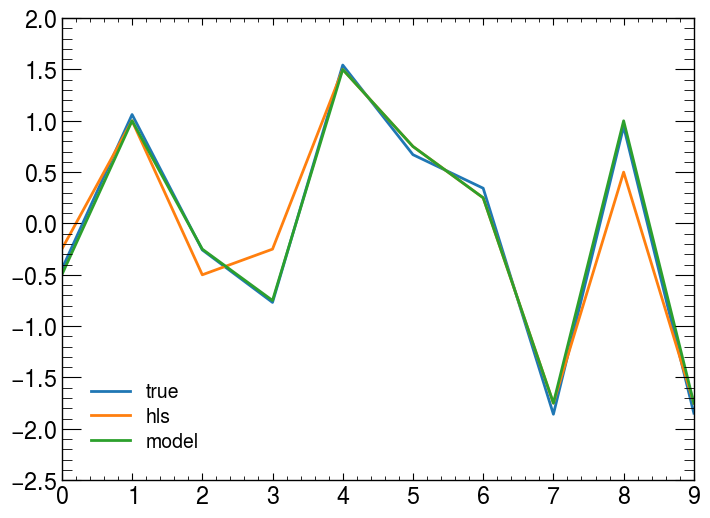

In [ ]:
plt.plot(t[0], label='true')
plt.plot(h.ravel(), label='hls')
plt.plot(m.ravel(), label='model')
plt.legend()
plt.show()

In [ ]:
tf.matmul(model_.predict(d[1:2]), model.layers[-1].qkernel) + model.layers[-1].qbias - model.predict(d[1:2])

1/1 [==============================] - 0s 19ms/step


<tf.Tensor: shape=(1, 10), dtype=float32, numpy=
array([[ 0.05419922,  0.06115723, -0.00744629, -0.01879883,  0.04296875,
        -0.07995605,  0.09326172, -0.10797119, -0.05615234, -0.09765625]],
      dtype=float32)>

In [ ]:
model_hls_ = convert_from_hgq_model(model_, output_dir='/tmp/hls4ml_prj_', project_name='hls4ml_prj_', backend='Vivado', io_type='io_parallel', inline_everything=True)

Interpreting Model
Topology:
Layer name: inp_q, layer type: InputLayer, input shapes: [[None, 10, 10, 1]], output shape: [None, 10, 10, 1]
Layer name: h_conv2d_2, layer type: Conv2D, input shapes: [[None, 10, 10, 1]], output shape: [None, 8, 8, 2]
Layer name: p_max_pool2d_2, layer type: MaxPooling2D, input shapes: [[None, 8, 8, 2]], output shape: [None, 4, 4, 2]
Layer name: p_reshape_2, layer type: Reshape, input shapes: [[None, 4, 4, 2]], output shape: [None, 8, 4]
Layer name: h_conv1d_2, layer type: Conv1D, input shapes: [[None, 8, 4]], output shape: [None, 6, 4]
Layer name: p_max_pool1d_2, layer type: MaxPooling1D, input shapes: [[None, 6, 4]], output shape: [None, 3, 4]
Layer name: p_flatten_2, layer type: Reshape, input shapes: [[None, 3, 4]], output shape: [None, 12]
Interpreting Model
Topology:
Layer name: inp_q, layer type: InputLayer, input shapes: [[None, 10, 10, 1]], output shape: [None, 10, 10, 1]
Layer name: h_conv2d_2, layer type: Conv2D, input shapes: [[None, 10, 10, 1]]

In [ ]:
model_hls_.compile()

Writing HLS project
Done


In [ ]:
model_hls_.predict(d[1:2])

array([0.25, 0.  , 0.75, 2.  , 1.  , 0.5 , 2.  , 0.75, 0.75, 0.5 , 1.25,
       3.  ], dtype=float32)